In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("bumba5341/advertisingcsv")

print("Path to dataset files:", path)

Path to dataset files: /Users/parham/.cache/kagglehub/datasets/bumba5341/advertisingcsv/versions/1


In [4]:
import os
df=pd.read_csv(os.path.join(path, "advertising.csv"))
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


In [5]:
df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [6]:
df.drop(["Unnamed: 0"], axis=1, inplace=True)

In [8]:
def ScatterPlot(feature,target):
    plt.Figure(figsize=(10, 6))
    plt.scatter(df[feature], df[target],c="blue")
    plt.xlabel("money spent on " + feature)
    plt.ylabel("sales")
    plt.show()

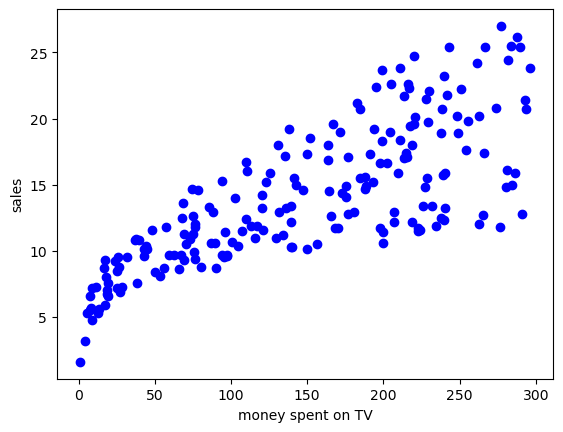

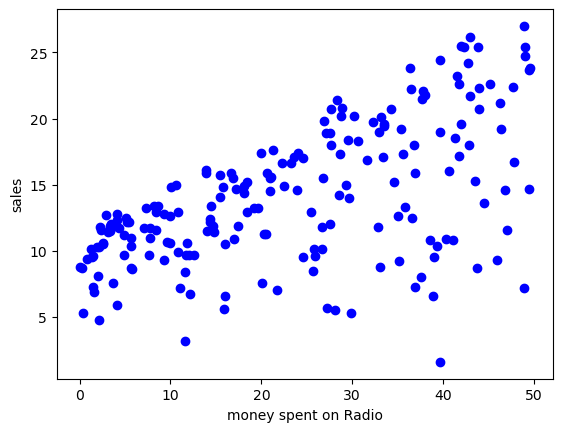

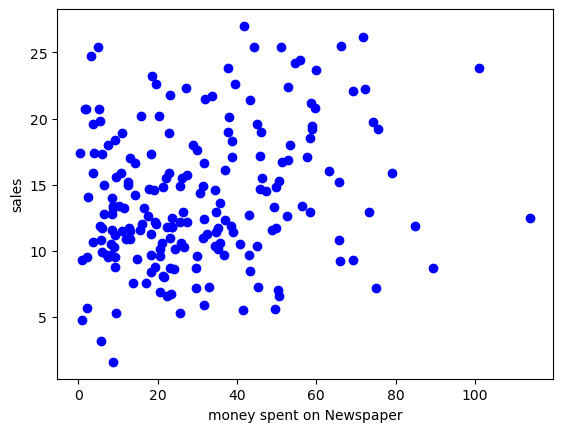

In [11]:
ScatterPlot("TV","Sales")
ScatterPlot("Radio","Sales")
ScatterPlot("Newspaper","Sales")

In [16]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
X=df.drop("Sales", axis=1)
y=df["Sales"].values.reshape(-1,1)
model=LinearRegression()
cross_validation_score=cross_val_score(model,X,y,cv=5,scoring='neg_mean_squared_error').mean()
print("Cross validation score:", cross_validation_score)

Cross validation score: -3.07294659710021


In [17]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
parameters={"alpha":[1e-15,1e-10,1e-8,1e-4,1e-3,1e-2,1,5,10,20,30,35,40,45,50,55,60,65,70,75,80,85,90,95,100]}
ridge=Ridge()
ridge_regression=GridSearchCV(ridge,parameters,cv=5,scoring='neg_mean_squared_error')
ridge_regression.fit(X,y)
print("Best alpha value:", ridge_regression.best_params_)
print("Best score:", ridge_regression.best_score_)

Best alpha value: {'alpha': 100}
Best score: -3.0716375765484765


In [18]:
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV
parameters={"alpha":[1e-15,1e-10,1e-8,1e-4,1e-3,1e-2,1,5,10,20,30,35,40,45,50,55,60,65,70,75,80,85,90,95,100]}
lasso=Lasso()
lasso_regression=GridSearchCV(lasso,parameters,cv=5,scoring='neg_mean_squared_error')
lasso_regression.fit(X,y)
print("Best alpha value:", lasso_regression.best_params_)
print("Best score:", lasso_regression.best_score_)

Best alpha value: {'alpha': 1}
Best score: -3.0414058967513697


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.086e+02, tolerance: 4.383e-01
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.385e+02, tolerance: 4.503e-01
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.200e+02, toler

-Ridge: “keep all features, but make coefficients smaller”

-Lasso: “make coefficients smaller, and maybe remove some features completely”